In [1]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from torch.utils.data.dataset import TensorDataset
from torch.utils.data import DataLoader

Text(0, 0.5, 'Y')

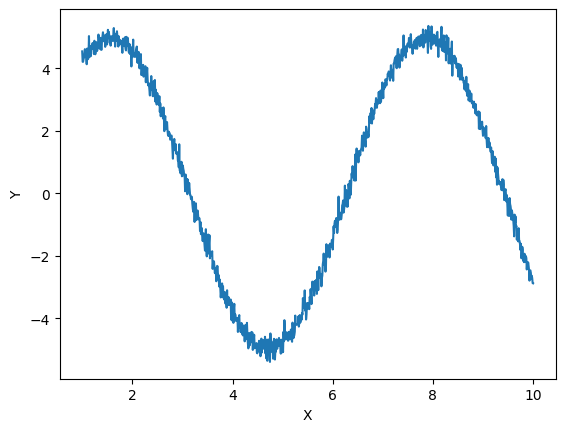

In [2]:
## Data generation

N_data = 1000
data_x = np.linspace(1.0, 10.0, N_data)[:, np.newaxis]
data_y = 5*np.sin(data_x) + 0.2*np.random.randn(N_data,1)

plt.plot( data_x.flatten(), data_y.flatten()  )
plt.xlabel('X')
plt.ylabel('Y')

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(data_x, data_y, test_size=0.2, random_state=42)

x_train = torch.FloatTensor(X_train)
x_valid = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(Y_train)
y_valid = torch.FloatTensor(Y_test)

train_ds = TensorDataset(x_train,y_train)
valid_ds = TensorDataset(x_valid,y_valid)

# Dataloader creation; used to batch together items for training, it returns multiple (x,y) every time you loop over it
dataloader = DataLoader(train_ds,batch_size=10,shuffle=True)

In [5]:
## Architecture

class Net(torch.nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        self.layer1 = torch.nn.Linear(1,10)
        self.layer2 = torch.nn.Linear(10,40)
        self.layer3 = torch.nn.Linear(40,80)
        self.layer4 = torch.nn.Linear(80,40)
        self.layer5 = torch.nn.Linear(40,10)
        self.layer6 = torch.nn.Linear(10,1)
        self.activation1 = torch.nn.ReLU()

    def forward(self,x):

        out = self.layer1(x)
        out = self.activation1(out)
        out = self.layer2(out)
        out = self.activation1(out)
        out = self.layer3(out)
        out = self.activation1(out)
        out = self.layer4(out)
        out = self.activation1(out)
        out = self.layer5(out)
        out = self.activation1(out)
        out = self.layer6(out)

        return out

net = Net()
net

Net(
  (layer1): Linear(in_features=1, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=40, bias=True)
  (layer3): Linear(in_features=40, out_features=80, bias=True)
  (layer4): Linear(in_features=80, out_features=40, bias=True)
  (layer5): Linear(in_features=40, out_features=10, bias=True)
  (layer6): Linear(in_features=10, out_features=1, bias=True)
  (activation1): ReLU()
)

In [7]:
## Training

# Definition of the loss function
def loss_func(true,pred):
    return torch.sum((true-pred)**2)
loss_func_pre = torch.nn.MSELoss()

# Pick up the Adam optimizer
optimizer = torch.optim.Adam(net.parameters(), lr=0.0001)

#loop over epochs
for epoch in  range(100):
    #loop over batches
    for x,y in dataloader:
        optimizer.zero_grad()
        output = net(x)
        loss = loss_func_pre(y,output)
        loss.backward()
        optimizer.step()

Text(0, 0.5, 'Y')

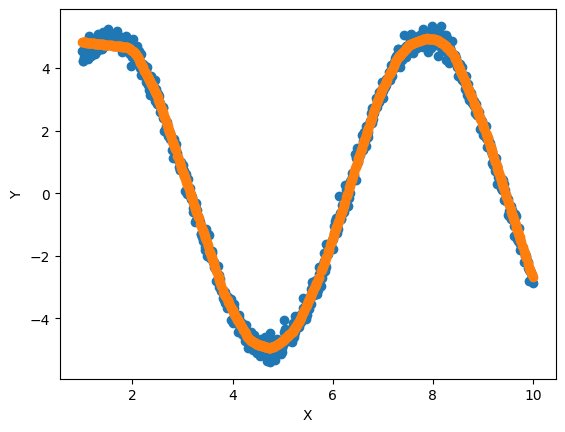

In [8]:
## Evaluation

data_pred=net(x_train)
plt.scatter(x_train, y_train )
plt.scatter(x_train,data_pred.detach().numpy() )
plt.xlabel('X')
plt.ylabel('Y')